In [6]:
from nilearn.datasets import fetch_abide_pcp

def load_abide(n_subjects=20):
    data = fetch_abide_pcp(
        data_dir='../data/',
        pipeline='cpac',
        band_pass_filtering=True,
        global_signal_regression=True,
        n_subjects=n_subjects
    )
    return data

## fMRI → ROI → Time Series → Graph → Coarsening → ML Model → Prediction

In [7]:
data = load_abide(20)

[fetch_abide_pcp] Added README.md to ../data/
[fetch_abide_pcp] Dataset created in ..\data\ABIDE_pcp
[fetch_abide_pcp] Downloading data from https://s3.amazonaws.com/fcp-indi/data/Projects/ABIDE_Initiative/Phenotypic_V1_0b_preprocessed1.csv ...
Downloaded 401408 of 449443 bytes (89.3%%,    0.1s remaining)
[fetch_abide_pcp]  ...done. (2 seconds, 0 min)

[fetch_abide_pcp] Downloading data from https://s3.amazonaws.com/fcp-indi/data/Projects/ABIDE_Initiative/Outputs/cpac/filt_global/func_preproc/Pitt_0050003_func_preproc.nii.gz ...
Downloaded 319488 of 104470867 bytes (0.3%%,  5.6min remaining)
Downloaded 1417216 of 104470867 bytes (1.4%%,  2.5min remaining)
Downloaded 3112960 of 104470867 bytes (3.0%%,  1.7min remaining)
Downloaded 4620288 of 104470867 bytes (4.4%%,  1.5min remaining)
Downloaded 6225920 of 104470867 bytes (6.0%%,  1.4min remaining)
Downloaded 7569408 of 104470867 bytes (7.2%%,  1.3min remaining)
Downloaded 8847360 of 104470867 bytes (8.5%%,  1.3min remaining)
Downloaded 

In [9]:
print(data.keys())

dict_keys(['description', 'phenotypic', 'func_preproc'])


In [10]:
import os
print(os.getcwd())

C:\Users\nitin\Final Year Project\src


In [11]:
print(data.func_preproc[0])

..\data\ABIDE_pcp\cpac\filt_global\Pitt_0050003_func_preproc.nii.gz


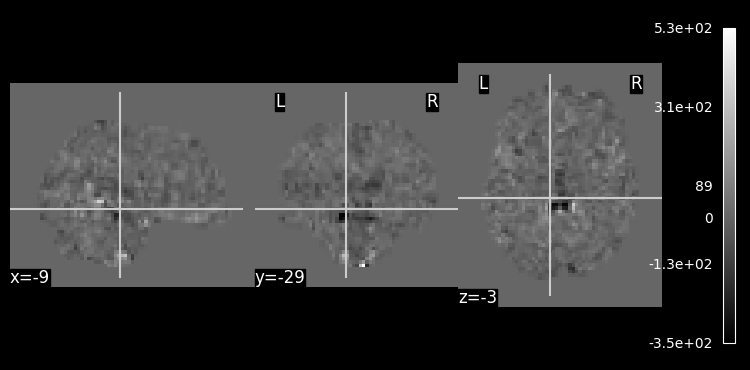

In [13]:
from nilearn import image, plotting

img_3d = image.index_img(data.func_preproc[0], 0)  # first time point
plotting.plot_epi(img_3d)

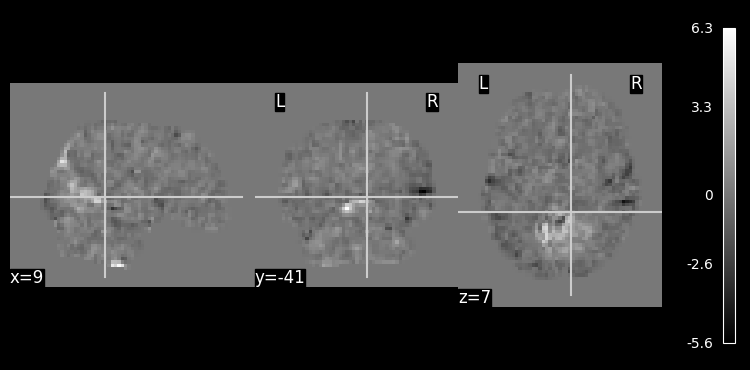

In [14]:
from nilearn import image, plotting

mean_img = image.mean_img(data.func_preproc[0])
plotting.plot_epi(mean_img)

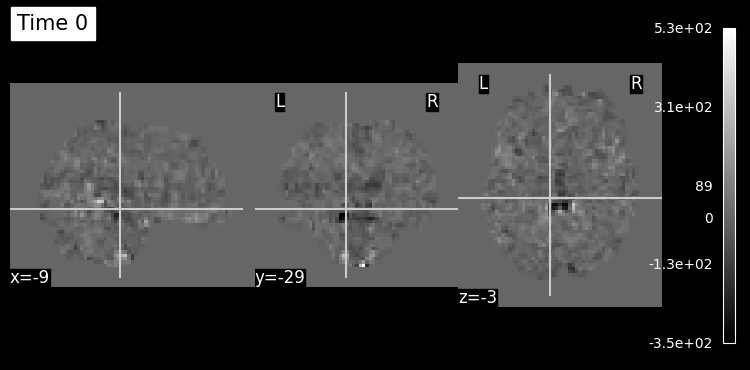

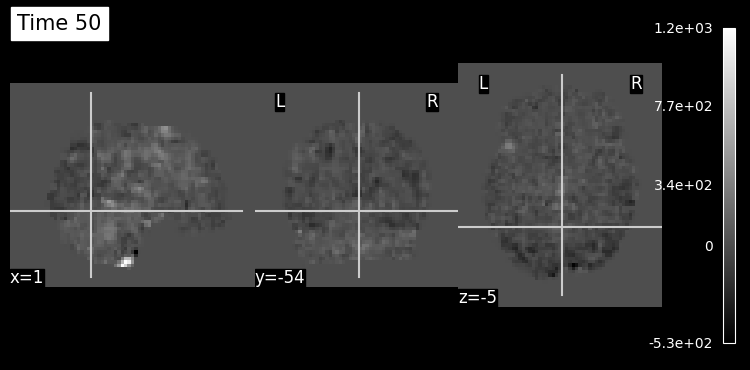

In [15]:
from nilearn import image, plotting

img_t0 = image.index_img(data.func_preproc[0], 0)
img_t50 = image.index_img(data.func_preproc[0], 50)

plotting.plot_epi(img_t0, title="Time 0")
plotting.plot_epi(img_t50, title="Time 50")

In [18]:
from nilearn import image

img = image.load_img(data.func_preproc[0])
print(img.shape)

(61, 73, 61, 196)


| Dimension | Meaning                      |
| --------- | ---------------------------- |
| 61        | brain width                  |
| 73        | brain height                 |
| 61        | brain depth                  |
| 176       | time points (VERY IMPORTANT) |


61 × 73 × 61 ≈ 271,000 voxels 🧠